In [1]:
import os

# uncomment to disable NVIDIA GPUs
#os.environ['CUDA_VISIBLE_DEVICES'] = ''
# or pick the device (cpu, gpu, and tpu)
#os.environ['JAX_PLATFORMS'] = 'cpu'

# change JAX GPU memory preallocation fraction
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.95'

# you do not want this
#os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true'

import jax
#jax.print_environment_info()

!nvidia-smi --query-gpu=gpu_name --format=csv,noheader

import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('jpeg')

from scraper import phase_space

from pmwd import (
    Configuration,
    Cosmology, SimpleLCDM,
    boltzmann, linear_power, growth,
    white_noise, linear_modes,
    lpt,
    nbody,
    scatter,
)
from pmwd.pm_util import fftinv
from pmwd.spec_util import powspec
from pmwd.vis_util import simshow

/bin/bash: linha 1: nvidia-smi: comando não encontrado


In [2]:
if jax.default_backend() == 'gpu':
    ptcl_spacing = 1.  # Lagrangian space Cartesian particle grid spacing, in Mpc/h by default
    ptcl_grid_shape = (256,) * 3
else:
    ptcl_spacing = 4.
    ptcl_grid_shape = (128,) * 3

conf = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=2)  # 2x mesh shape


print(conf)  # with other default parameters
print(f'Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps.')

Configuration(ptcl_spacing=4.0,
              ptcl_grid_shape=(128, 128, 128),
              mesh_shape=(256, 256, 256),
              cosmo_dtype=dtype('float64'),
              pmid_dtype=dtype('int16'),
              float_dtype=dtype('float32'),
              k_pivot_Mpc=0.05,
              T_cmb=2.7255,
              M=1.98847e+40,
              L=3.0856775815e+22,
              T=3.0856775815e+17,
              transfer_fit=True,
              transfer_fit_nowiggle=False,
              transfer_lgk_min=-4,
              transfer_lgk_max=3,
              transfer_lgk_maxstep=0.0078125,
              growth_rtol=1.4901161193847656e-08,
              growth_atol=1.4901161193847656e-08,
              growth_inistep=(1, None),
              lpt_order=2,
              a_start=0.015625,
              a_stop=1,
              a_lpt_maxstep=0.0078125,
              a_nbody_maxstep=0.015625,
              symp_splits=((0, 0.5), (1, 0.5)),
              chunk_size=16777216)
Simulating 209715

In [3]:
cosmo = SimpleLCDM(conf)
print(cosmo)

Cosmology(A_s_1e9=Array(2., dtype=float64),
          n_s=Array(0.96, dtype=float64),
          Omega_m=Array(0.3, dtype=float64),
          Omega_b=Array(0.05, dtype=float64),
          h=Array(0.7, dtype=float64),
          Omega_k_=None,
          w_0_=None,
          w_a_=None,
          mu_0_=None,
          transfer=None,
          growth=None,
          growth_kgrid=None,
          varlin=None)


In [4]:
%time cosmo = jax.block_until_ready(boltzmann(cosmo, conf))
modes = white_noise( 0 , conf)
modes = linear_modes(modes, cosmo, conf)
%time ptcl, obsvbl = jax.block_until_ready(lpt(modes, cosmo, conf))
#%time jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))
%time ptcl, obsvbl = jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))

CPU times: user 891 ms, sys: 48.7 ms, total: 940 ms
Wall time: 594 ms
CPU times: user 627 ms, sys: 78.4 ms, total: 705 ms
Wall time: 307 ms
CPU times: user 1min 3s, sys: 43.5 s, total: 1min 47s
Wall time: 42.8 s


(<Figure size 604.8x470.4 with 2 Axes>, <Axes: >)

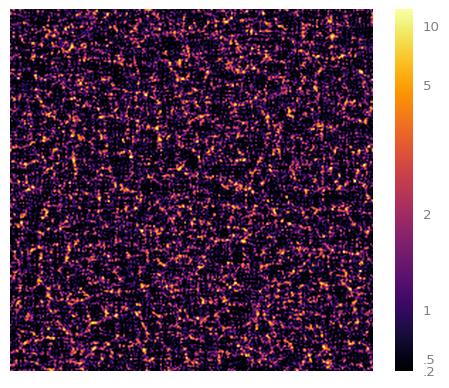

In [5]:
dens = scatter(ptcl, conf)
simshow(dens[:16].mean(axis=0), norm='CosmicWebNorm')

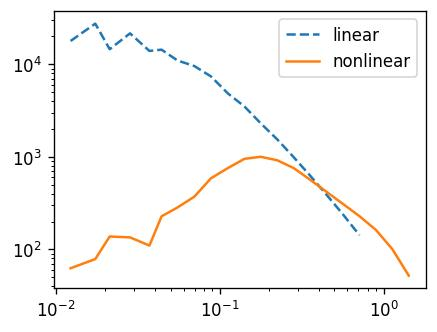

In [6]:
k, P, _, _ = powspec(dens, conf.cell_size)

dens_lin = fftinv(modes, shape=conf.ptcl_grid_shape, norm=conf.ptcl_spacing)
dens_lin *= growth(conf.a_stop, cosmo, conf)
k_lin, P_lin, _, _ = powspec(dens_lin, conf.ptcl_spacing)

P_linth = linear_power(k, conf.a_stop, cosmo, conf)

plt.figure(figsize=(4, 3), dpi=120)
#plt.loglog(k, P_linth, ls='--', label='linear theory')
plt.loglog(k_lin, P_lin, ls='--', label='linear')
plt.loglog(k, P, ls='-', label='nonlinear')
plt.legend();

In [7]:
def nolin_ps(cosmo, modes):
    cosmo = jax.block_until_ready(boltzmann(cosmo, conf))
    modes = linear_modes(modes, cosmo, conf)
    ptcl, obsvbl = jax.block_until_ready(lpt(modes, cosmo, conf))
    ptcl, obsvbl = jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))
    dens = scatter(ptcl, conf)
    return powspec(dens, conf.cell_size)[:2]

def spec_save(cosmo, modes):
    cosmo = jax.block_until_ready(boltzmann(cosmo, conf))
    modes = linear_modes(modes, cosmo, conf)
    ptcl, obsvbl = jax.block_until_ready(lpt(modes, cosmo, conf))
    ptcl, obsvbl = jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))
    dens = scatter(ptcl, conf)
    return powspec(dens, conf.cell_size)[:2]

In [8]:
cosmo = SimpleLCDM(conf, mu_0_=0.0)
modes = white_noise(0, conf)
#mu_zeros = [-0.5, -0.2, 0.0, 0.2, 0.5]
mu_zeros = [-0.2, 0.0, 0.2]

for mu_0 in mu_zeros:
    cosmo = cosmo.replace(mu_0_=mu_0)
    k, P = nolin_ps(cosmo, modes)
    #phase_space(modes, cosmo, conf)
    plt.loglog(k, P, label=f'mu_0={mu_0:.1f}')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)$^3$]')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5, color='gray')
plt.figure(figsize=(24, 18), dpi=100)
plt.show()

KeyboardInterrupt: 